
# Notebook 1 — From Polls to Pulses to Observables

This notebook serves as the conceptual bridge for the project. We explore the mathematics of **Concentration Inequalities** in three contexts:

1.  **Polls (The "Utopia" Story):** Estimating voter support from a sample.
2.  **QKD (Quantum Key Distribution):** Estimating error rates from a subset of pulses.
3.  **Quantum Observables:** Estimating expectation values (e.g., $\langle Z \rangle$) from measurement shots.

In all three, the core object is a **sample mean of bounded random variables**.

**Goals:**
* Implement bounds: Markov, Chebyshev, Hoeffding, and Chernoff.
* **Compare sample-size requirements** (Shot budgets).
* **Compare Confidence Interval (CI) widths and coverage** (Accuracy vs. Cost).
* Establish the mathematical link to quantum observables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Plot styling for readability
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 12

# random seed for reproducibility
rng = np.random.default_rng(42)

## 1. Concentration Inequalities

We consider i.i.d. random variables $X_i \in \{0,1\}$ (Bernoulli) with mean $p$.
The estimator is $\hat{p} = \frac{1}{n} \sum X_i$.

We implement functions that return a **two-sided Confidence Interval (CI)** $[L, U]$ such that:
$$P(|\hat{p} - p| \ge \epsilon) \le \delta$$

In [3]:
def hoeffding_bound(p_est: float, n: int, delta: float):
    """
    Two-sided Hoeffding CI for variables bounded in [0,1].
    Radius = sqrt( ln(2/delta) / (2n) )
    """
    if n <= 0: return 0.0, 1.0
    radius = math.sqrt(math.log(2 / delta) / (2 * n))
    return max(0.0, p_est - radius), min(1.0, p_est + radius)

def chernoff_bound(p_est: float, n: int, delta: float):
    """
    A simplified Chernoff bound (often tighter than Hoeffding for small p).
    Radius approx: sqrt( 3 * ln(2/delta) / n )
    Note: There are many forms of Chernoff; this is a standard simplified form.
    """
    if n <= 0: return 0.0, 1.0
    radius = math.sqrt(3 * math.log(2 / delta) / n)
    return max(0.0, p_est - radius), min(1.0, p_est + radius)

def chebyshev_bound(p_est: float, n: int, delta: float):
    """
    Chebyshev CI using EMPIRICAL variance.
    Radius = sqrt( Var / (n * delta) )
    """
    if n <= 0: return 0.0, 1.0
    var_est = p_est * (1 - p_est)
    if var_est == 0: return p_est, p_est # Degenerate case
    
    radius = math.sqrt(var_est / (delta * n))
    return max(0.0, p_est - radius), min(1.0, p_est + radius)

def markov_bound(p_est: float, delta: float):
    """
    Markov inequality (included for contrast). 
    It is generally too loose to be useful for two-sided CIs on means.
    """
    radius = 1.0 / delta 
    return max(0.0, p_est - radius), min(1.0, p_est + radius)

## 2. Sample Size Planning (Shot Budgeting)

How many samples ($n$) do we need to ensure the error is $\le \epsilon$ with probability $1-\delta$?

In [4]:

# %%
def sample_size_hoeffding(epsilon: float, delta: float) -> int:
    # n >= ln(2/delta) / (2 * epsilon^2)
    return int(math.ceil((1.0 / (2 * epsilon**2)) * math.log(2.0 / delta)))

def sample_size_chernoff(epsilon: float, delta: float) -> int:
    # n >= 3 * ln(2/delta) / epsilon^2
    return int(math.ceil((3.0 / (epsilon**2)) * math.log(2.0 / delta)))

def sample_size_chebyshev(epsilon: float, delta: float) -> int:
    # Using worst-case variance (sigma^2 = 1/4)
    # n >= 1 / (4 * epsilon^2 * delta)
    return int(math.ceil(1.0 / (4 * epsilon**2 * delta)))

## 3. Comparison 1: Sample Size Requirements

Let's compare the "cost" (number of shots $n$) required by each bound to achieve a specific tolerance $\epsilon$.

* **Scenario:** Fixed $\delta = 0.05$ (95% confidence).
* **X-axis:** Tolerance $\epsilon$ (from strict 1% to loose 20%).
* **Y-axis:** Required $n$ (log scale).

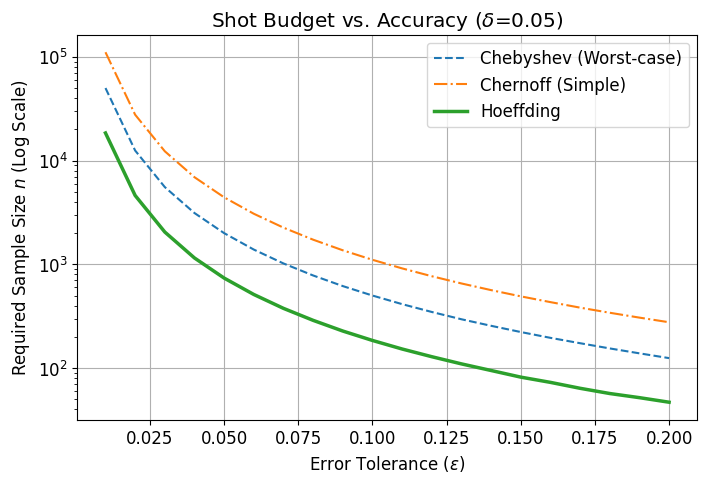

Cost at epsilon=0.05 (5% error):
Chebyshev: 2000 shots
Hoeffding: 738 shots


In [6]:
delta_fixed = 0.05
epsilons = np.linspace(0.01, 0.2, 20) 

n_cheb = [sample_size_chebyshev(e, delta_fixed) for e in epsilons]
n_hoef = [sample_size_hoeffding(e, delta_fixed) for e in epsilons]
n_cher = [sample_size_chernoff(e, delta_fixed) for e in epsilons]

plt.figure(figsize=(8, 5))
plt.plot(epsilons, n_cheb, label="Chebyshev (Worst-case)", linestyle='--')
plt.plot(epsilons, n_cher, label="Chernoff (Simple)", linestyle='-.')
plt.plot(epsilons, n_hoef, label="Hoeffding", linewidth=2.5)

plt.yscale("log")
plt.xlabel(r"Error Tolerance ($\epsilon$)")
plt.ylabel("Required Sample Size $n$ (Log Scale)")
plt.title(f"Shot Budget vs. Accuracy ($\\delta$={delta_fixed})")
plt.legend()
plt.show()

print(f"Cost at epsilon=0.05 (5% error):")
print(f"Chebyshev: {sample_size_chebyshev(0.05, 0.05)} shots")
print(f"Hoeffding: {sample_size_hoeffding(0.05, 0.05)} shots")

## 4. Story: Polls in Utopia
Imagine estimating support for a party in "Utopia".
* True support $\mu = 0.6$.
* We want error $\epsilon = 0.10$ with failure probability $\delta = 0.01$. We calculate the budget using Hoeffding, run 10,000 virtual polls, and check if the bound holds.

In [ ]:
# %%
true_mu = 0.6
epsilon = 0.10
delta = 0.01

# 1. Plan shots
n_required = sample_size_hoeffding(epsilon, delta)
print(f"Planned sample size (Hoeffding): n = {n_required}")

# 2. Simulate 10,000 polls
trials = 10_000
# Generate (trials x n) matrix of 0s and 1s
poll_data = rng.binomial(1, true_mu, size=(trials, n_required))
p_hats = poll_data.mean(axis=1)

# 3. Check failures
errors = np.abs(p_hats - true_mu)
failures = np.sum(errors >= epsilon)
failure_rate = failures / trials

print(f"Simulated Failure Rate: {failure_rate:.4f}")
print(f"Theoretical Bound (delta): {delta}")
print("Result: Hoeffding is valid (Simulated < Delta).")

## 5. Comparison 2: CI Width vs. True Coverage

A "valid" bound must contain the true value at least $1-\delta$ of the time.
However, if the bound is too loose (interval too wide), it's useless.

We compare:
1.  **Coverage:** Does the CI contain $\mu$? (Should be $\ge 95\%$)
2.  **Width:** How wide is the interval? (Narrower is better/cheaper)

In [7]:
def compare_ci_performance(mu, n, delta, trials=5000):
    results = {
        "Hoeffding": {"cover": 0, "width": 0.0},
        "Chernoff":  {"cover": 0, "width": 0.0},
        "Chebyshev": {"cover": 0, "width": 0.0}
    }
    
    for _ in range(trials):
        # Generate one experiment
        sample = rng.binomial(1, mu, size=n)
        p_hat = sample.mean()
        
        # Test all bounds
        for name, bound_func in [
            ("Hoeffding", hoeffding_bound),
            ("Chernoff", chernoff_bound),
            ("Chebyshev", chebyshev_bound)
        ]:
            low, high = bound_func(p_hat, n, delta)
            
            # Check coverage
            if low <= mu <= high:
                results[name]["cover"] += 1
            
            # Accumulate width
            results[name]["width"] += (high - low)

    # Summarize
    print(f"Simulation: mu={mu}, n={n}, delta={delta}, trials={trials}")
    print(f"{'Method':<12} | {'Coverage':<10} | {'Avg Width':<10}")
    print("-" * 40)
    for name, data in results.items():
        cov = data["cover"] / trials
        avg_w = data["width"] / trials
        print(f"{name:<12} | {cov:.4f}     | {avg_w:.4f}")

# Run the comparison
compare_ci_performance(mu=0.6, n=500, delta=0.05)

Simulation: mu=0.6, n=500, delta=0.05, trials=5000
Method       | Coverage   | Avg Width 
----------------------------------------
Hoeffding    | 0.9942     | 0.1215
Chernoff     | 1.0000     | 0.2975
Chebyshev    | 1.0000     | 0.1957


## 6. Story: QKD Parameter Estimation

In QKD, Alice and Bob share $N_{total}$ bits (pulses). They must estimate the error rate of the *whole* string by revealing only a small subset ($n_{test}$).

* **Test Set:** $n_{test}$ bits (Publicly revealed). Estimate $\hat{p}$.
* **Key Set:** Remaining bits (Private). True error rate $q_{key}$.

If $\hat{p}$ is low, they trust $q_{key}$ is also low. If $q_{key}$ is actually high (outside the bound), the protocol fails (security breach).


In [8]:
mu_global = 0.03       # True underlying error rate (3%)
N_total = 100_000      # Total pulses
n_test = 5_000         # Pulses sacrificed for testing
delta_qkd = 1e-6       # Strict security parameter

# Simulate one QKD session
errors = rng.binomial(1, mu_global, size=N_total)

# Split into Test and Key
indices = np.arange(N_total)
rng.shuffle(indices)
test_idx = indices[:n_test]
key_idx = indices[n_test:]

p_test = errors[test_idx].mean() # Revealed error
q_key = errors[key_idx].mean()   # Hidden error (Target)

# Calculate Hoeffding Upper Bound based on p_test
_, upper_bound = hoeffding_bound(p_test, n_test, delta_qkd)

print(f"--- QKD Simulation ---")
print(f"Test Error (p_test): {p_test:.5f}")
print(f"Hoeffding Limit:     {upper_bound:.5f} (Trust threshold)")
print(f"Actual Key Error:    {q_key:.5f}")

if q_key <= upper_bound:
    print("SUCCESS: Key error is within the predicted bound. Safe to distill.")
else:
    print("FAILURE: Key error violated the bound! (Security risk).")

--- QKD Simulation ---
Test Error (p_test): 0.02960
Hoeffding Limit:     0.06769 (Trust threshold)
Actual Key Error:    0.02993
SUCCESS: Key error is within the predicted bound. Safe to distill.


## 7. Conclusion: The Bridge to Observables

We have seen that whether we are polling voters or testing QKD pulses, the math is the same: **Estimating the mean of a bounded variable.**

This applies directly to Quantum Observables in VQE or Estimator primitives:

1.  **Pauli Measurement:** Measuring $Z$ gives outcomes $\{+1, -1\}$.
2.  **Rescaling:** We can map this to $\{0, 1\}$ via $X = \frac{Z+1}{2}$.
3.  **The Shot Budget:** The number of shots $n$ required to estimate $\langle H \rangle$ to accuracy is determined by these exact inequalities (usually Hoeffding).

**Next Steps (Notebook 2):**
* We will take a real quantum circuit (Swap Test).
* We will use Qiskit Runtime to run it with specific shot budgets.
